# spaCy en acción: pipeline completo y material de apoyo

**Duración estimada:** 35 minutos

## Propósito
Este notebook funciona como material de consolidación. Reúne en un mismo recorrido las etapas principales del pipeline de `spaCy` y las conecta con una aplicación sencilla de extracción de palabras clave.

## Relación con el notebook anterior
- En `001_spacy_fundamentos.ipynb` trabajaste ejemplos breves y focalizados.
- Acá vas a mirar un flujo más continuo: texto -> procesamiento -> análisis -> visualización.


In [ ]:
#!pip install spacy -q
#!python -m spacy download es_core_news_sm -q


In [1]:
import spacy
from collections import Counter
from spacy import displacy
from wordcloud import WordCloud
import matplotlib.pyplot as plt

nlp = spacy.load("es_core_news_sm")


## 1. El pipeline en una sola mirada

Cuando procesas un texto con `spaCy`, el modelo aplica una secuencia de operaciones. Ver ese pipeline te ayuda a entender por qué después aparecen tokens, lemas, dependencias y entidades.


In [2]:
print(nlp.pipe_names)


['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


In [3]:
texto_ejemplo = "YPF anunció nuevas inversiones en Vaca Muerta para ampliar la producción de energía en Argentina."
doc = nlp(texto_ejemplo)
print(texto_ejemplo)


YPF anunció nuevas inversiones en Vaca Muerta para ampliar la producción de energía en Argentina.


## 2. Tokenización

Primer paso: observar cómo el modelo divide el texto.


In [4]:
tokens = [token.text for token in doc]
print(tokens)


['YPF', 'anunció', 'nuevas', 'inversiones', 'en', 'Vaca', 'Muerta', 'para', 'ampliar', 'la', 'producción', 'de', 'energía', 'en', 'Argentina', '.']


## 3. Lematización

Ahora miramos la forma base de cada token, excluyendo puntuación y espacios para que la salida quede más clara.


In [5]:
for token in doc:
    if not token.is_punct and not token.is_space:
        print(f"'{token.text}' -> '{token.lemma_}'")


'YPF' -> 'YPF'
'anunció' -> 'anunciar'
'nuevas' -> 'nuevo'
'inversiones' -> 'inversión'
'en' -> 'en'
'Vaca' -> 'Vaca'
'Muerta' -> 'Muerta'
'para' -> 'para'
'ampliar' -> 'ampliar'
'la' -> 'el'
'producción' -> 'producción'
'de' -> 'de'
'energía' -> 'energía'
'en' -> 'en'
'Argentina' -> 'Argentina'


## 4. Etiquetado gramatical (POS)

Esta salida te permite leer qué rol gramatical cumple cada palabra dentro del texto.


In [6]:
for token in doc:
    if not token.is_space:
        print(f"'{token.text}' -> {token.pos_} ({spacy.explain(token.pos_)}) -> {token.tag_}")


'YPF' -> PROPN (proper noun) -> PROPN
'anunció' -> VERB (verb) -> VERB
'nuevas' -> ADJ (adjective) -> ADJ
'inversiones' -> NOUN (noun) -> NOUN
'en' -> ADP (adposition) -> ADP
'Vaca' -> PROPN (proper noun) -> PROPN
'Muerta' -> PROPN (proper noun) -> PROPN
'para' -> ADP (adposition) -> ADP
'ampliar' -> VERB (verb) -> VERB
'la' -> DET (determiner) -> DET
'producción' -> NOUN (noun) -> NOUN
'de' -> ADP (adposition) -> ADP
'energía' -> NOUN (noun) -> NOUN
'en' -> ADP (adposition) -> ADP
'Argentina' -> PROPN (proper noun) -> PROPN
'.' -> PUNCT (punctuation) -> PUNCT


## 5. Dependencias sintácticas

Acá aparece la relación entre cada token y su palabra cabeza. Esta información es muy útil para interpretar estructura.


In [7]:
for token in doc:
    if not token.is_space:
        print(f"'{token.text}' -> {token.dep_} ({spacy.explain(token.dep_)}) -> '{token.head.text}'")


'YPF' -> nsubj (nominal subject) -> 'anunció'
'anunció' -> ROOT (root) -> 'anunció'
'nuevas' -> amod (adjectival modifier) -> 'inversiones'
'inversiones' -> obj (object) -> 'anunció'
'en' -> case (case marking) -> 'Vaca'
'Vaca' -> obl (oblique nominal) -> 'anunció'
'Muerta' -> flat (flat multiword expression) -> 'Vaca'
'para' -> mark (marker) -> 'ampliar'
'ampliar' -> advcl (adverbial clause modifier) -> 'anunció'
'la' -> det (determiner) -> 'producción'
'producción' -> obj (object) -> 'ampliar'
'de' -> case (case marking) -> 'energía'
'energía' -> nmod (modifier of nominal) -> 'producción'
'en' -> case (case marking) -> 'Argentina'
'Argentina' -> nmod (modifier of nominal) -> 'producción'
'.' -> punct (punctuation) -> 'anunció'


In [8]:
displacy.render(doc, style='dep', jupyter=True, options={'distance': 120})


## 6. Reconocimiento de entidades nombradas

En este ejemplo, el foco está puesto en detectar organizaciones y lugares relevantes.


In [9]:
if doc.ents:
    print("Entidades encontradas:")
    print("Texto de la entidad -> Etiqueta (tipo)")
    for ent in doc.ents:
        print(f"'{ent.text}' -> {ent.label_} ({spacy.explain(ent.label_)})")
else:
    print("No se encontraron entidades nombradas en este texto.")


Entidades encontradas:
Texto de la entidad -> Etiqueta (tipo)
'YPF' -> ORG (Companies, agencies, institutions, etc.)
'Vaca Muerta' -> LOC (Non-GPE locations, mountain ranges, bodies of water)
'Argentina' -> LOC (Non-GPE locations, mountain ranges, bodies of water)


In [10]:
displacy.render(doc, style='ent', jupyter=True, options={'distance': 200})


## 7. Ejemplo aplicado: palabras clave en un texto expositivo

Hasta ahora trabajamos con un ejemplo breve. En esta parte vamos a usar un texto más largo para extraer palabras clave y visualizar sus frecuencias.


In [10]:
wiki_txt = """
La fotosíntesis es el proceso químico fundamental mediante el cual las plantas verdes,
algas y algunas bacterias convierten la energía lumínica del sol en energía química.
Utilizan dióxido de carbono del aire y agua del suelo para producir glucosa,
su alimento principal, liberando oxígeno como subproducto. La clorofila,
un pigmento verde en los cloroplastos, es crucial para capturar esta energía solar.
Este proceso sustenta casi toda la vida en la Tierra.
"""

print(wiki_txt[:180] + "...")
doc = nlp(wiki_txt)
print("Texto procesado.")



La fotosíntesis es el proceso químico fundamental mediante el cual las plantas verdes,
algas y algunas bacterias convierten la energía lumínica del sol en energía química.
Utiliza...
Texto procesado.


## 8. Extracción de palabras clave

En esta estrategia nos quedamos con tokens alfabéticos que no son stopwords y usamos el lema para agrupar variantes.


In [11]:
palabras_clave = []
for token in doc:
    if token.is_alpha and not token.is_stop:
        palabras_clave.append(token.lemma_.lower())

print(f"Se extrajeron {len(palabras_clave)} palabras clave.")
print("Ejemplo:", palabras_clave[:15])


Se extrajeron 39 palabras clave.
Ejemplo: ['fotosíntesis', 'proceso', 'químico', 'fundamental', 'planta', 'verde', 'alga', 'bacteria', 'convertir', 'energía', 'lumínico', 'sol', 'energía', 'químico', 'utilizar']


In [12]:
frecuencia_palabras = Counter(palabras_clave)
palabras_mas_comunes = frecuencia_palabras.most_common(15)

for palabra, frecuencia in palabras_mas_comunes:
    print(f"- '{palabra}': {frecuencia}")


- 'energía': 3
- 'proceso': 2
- 'químico': 2
- 'verde': 2
- 'fotosíntesis': 1
- 'fundamental': 1
- 'planta': 1
- 'alga': 1
- 'bacteria': 1
- 'convertir': 1
- 'lumínico': 1
- 'sol': 1
- 'utilizar': 1
- 'dióxido': 1
- 'carbono': 1


## 9. Visualización

La nube de palabras no reemplaza el análisis, pero puede ayudarte a detectar temas dominantes de manera rápida.


In [13]:
wordcloud_generator = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    max_words=50,
    collocations=False,
).generate_from_frequencies(frecuencia_palabras)


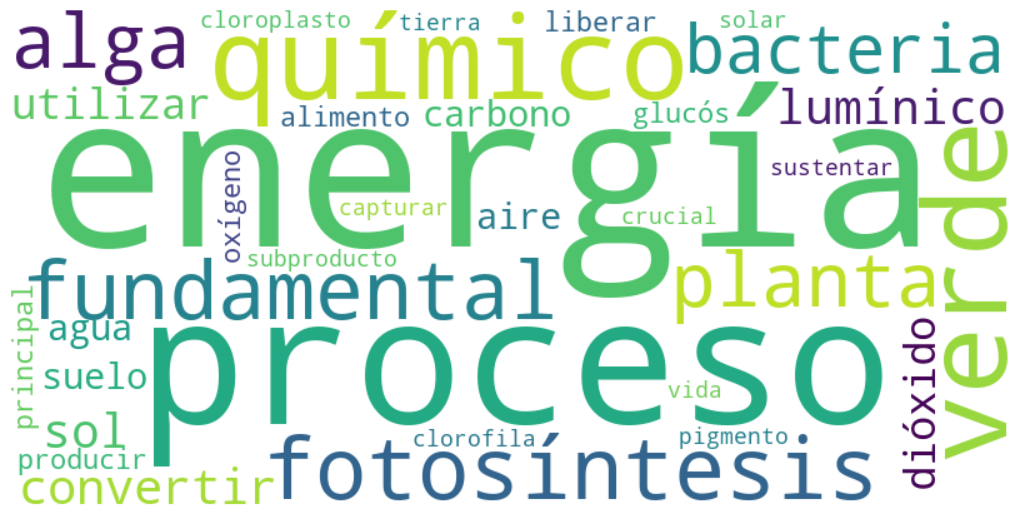

In [15]:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_generator, interpolation='bilinear')
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()


## Cierre y puente hacia el prelaboratorio

Si querés profundizar este material, probá este ejercicio:
1. Pedile a un asistente de IA que te proponga cinco palabras clave posibles para el texto sobre fotosíntesis.
2. Compará esa selección con `palabras_mas_comunes`.
3. Explicá cuáles conservarías, cuáles descartarías y por qué.

En el próximo notebook vas a aplicar esta lógica a una noticia, con un foco más claro en lectura crítica y preparación para el laboratorio.


### Estas son las 5 palabras que me propone el asistente

Para este texto sobre la fotosíntesis, las palabras clave deben representar tanto a los actores (quiénes lo hacen) como al proceso y los insumos (qué entra y qué sale).

Aquí tienes mi propuesta de 5 palabras clave basada en un análisis de relevancia semántica:

```

Fotosíntesis: El concepto central y título del proceso químico.

Energía lumínica: La fuente de entrada indispensable que el proceso transforma.

Clorofila: El componente biológico crucial (pigmento) que permite la captura de energía.

Glucosa: El producto principal y objetivo del proceso (el alimento).

Oxígeno: El subproducto vital que se libera a la atmósfera.
```

In [14]:
frecuencia_palabras = Counter(palabras_clave)
palabras_mas_comunes = frecuencia_palabras.most_common(len(frecuencia_palabras))

for palabra, frecuencia in palabras_mas_comunes:
    print(f"- '{palabra}': {frecuencia}")


- 'energía': 3
- 'proceso': 2
- 'químico': 2
- 'verde': 2
- 'fotosíntesis': 1
- 'fundamental': 1
- 'planta': 1
- 'alga': 1
- 'bacteria': 1
- 'convertir': 1
- 'lumínico': 1
- 'sol': 1
- 'utilizar': 1
- 'dióxido': 1
- 'carbono': 1
- 'aire': 1
- 'agua': 1
- 'suelo': 1
- 'producir': 1
- 'glucós': 1
- 'alimento': 1
- 'principal': 1
- 'liberar': 1
- 'oxígeno': 1
- 'subproducto': 1
- 'clorofila': 1
- 'pigmento': 1
- 'cloroplasto': 1
- 'crucial': 1
- 'capturar': 1
- 'solar': 1
- 'sustentar': 1
- 'vida': 1
- 'tierra': 1


El asistente realizó un análisis semántico para elegir las 5 palabras claves.
En nuestro proceso con counter obtenemos la frecuencia de palabras, se observa que no aparece "clorofila" y el asistente la pone en tercer lugar, con "fotosíntesis" la frecuencia es uno y el asistente la coloca en primer lugar.
"Glucosa" es lo más importante para las plantas porque es su alimento, mientras el oxígeno es algo que descarta.
"Energía" es la única palabra que el asistente le da relevancia en base a su frecuencia